# Week 1 Day 5 — Logistic Regression from Scratch

## What I built:
- Implemented sigmoid function from scratch
- Loaded and normalized Titanic data
- Built logistic regression with gradient descent — 1000 epochs
- Plotted learning curve — loss goes down smoothly
- Evaluated with confusion matrix, precision, recall
- Compared results with sklearn

## Key concepts:
- Sigmoid converts any number to probability between 0 and 1
- Loss = how wrong the model is — gradient descent minimizes it
- Each epoch adjusts weights slightly to reduce loss
- Learning rate controls how big each adjustment step is

## Results:
- Accuracy  : ~70%
- Precision : 0.67
- Recall    : 0.45
- Low recall because only 2 features used — will improve in Week 2

# Sigmoid Function

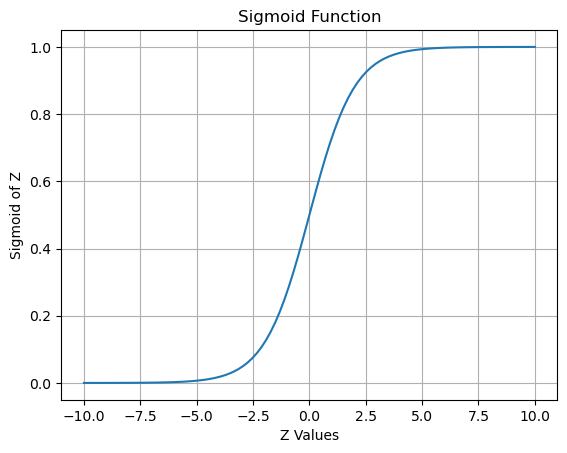

In [7]:
import matplotlib.pyplot as plt
import numpy as np
def sigmoid(z):
    return 1/(1+ np.exp(-z))
z = np.linspace(-10, 10, 100)  # 100 points from -10 to 10
plt.title('Sigmoid Function')
plt.xlabel('Z Values')
plt.ylabel('Sigmoid of Z')
plt.plot(z,sigmoid(z))
plt.grid(True)
plt.show()

# Load Titanic Data and Prepare Features

In [9]:
import pandas as pd

df = pd.read_csv('Titanic-Dataset.csv')

# fill missing values
df['Age'] = df['Age'].fillna(df['Age'].median())

# encode Sex — male=0, female=1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# select only 2 features for now
X = df[['Age', 'Pclass']].values   # numpy array
y = df['Survived'].values           # numpy array

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Sample X:\n", X[:5])
print("Sample y:", y[:5])

X shape: (891, 2)
y shape: (891,)
Sample X:
 [[22.  3.]
 [38.  1.]
 [26.  3.]
 [35.  1.]
 [35.  3.]]
Sample y: [0 1 1 1 0]


# Normalize The Feature

In [10]:
# normalize — subtract mean, divide by std
X_mean = X.mean(axis=0)
X_std  = X.std(axis=0)
X_norm = (X - X_mean) / X_std

print("Before normalization - Age mean:", X[:,0].mean().round(2))
print("After normalization  - Age mean:", X_norm[:,0].mean().round(2))

Before normalization - Age mean: 29.36
After normalization  - Age mean: 0.0


# Implement Logistic Regression With Gradient Descent

In [11]:
# ── Hyperparameters ──────────────────────────────────────────
learning_rate = 0.01
epochs        = 1000

# ── Initialize weights and bias ──────────────────────────────
np.random.seed(42)
weights = np.zeros(X_norm.shape[1])  # one weight per feature → shape (2,)
bias    = 0

# ── Gradient Descent Loop ────────────────────────────────────
loss_history = []

for epoch in range(epochs):
    # Step 1 — forward pass (make predictions)
    z         = np.dot(X_norm, weights) + bias
    y_pred    = sigmoid(z)

    # Step 2 — calculate loss (binary cross entropy)
    loss = -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
    loss_history.append(loss)

    # Step 3 — calculate gradients
    error      = y_pred - y
    dw         = np.dot(X_norm.T, error) / len(y)
    db         = np.mean(error)

    # Step 4 — update weights
    weights = weights - learning_rate * dw
    bias    = bias    - learning_rate * db

    # Print loss every 100 epochs
    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d} → Loss: {loss:.4f}")

Epoch    0 → Loss: 0.6931
Epoch  100 → Loss: 0.6596
Epoch  200 → Loss: 0.6380
Epoch  300 → Loss: 0.6236
Epoch  400 → Loss: 0.6139
Epoch  500 → Loss: 0.6071
Epoch  600 → Loss: 0.6022
Epoch  700 → Loss: 0.5987
Epoch  800 → Loss: 0.5961
Epoch  900 → Loss: 0.5942


# Plot The Learning Curve

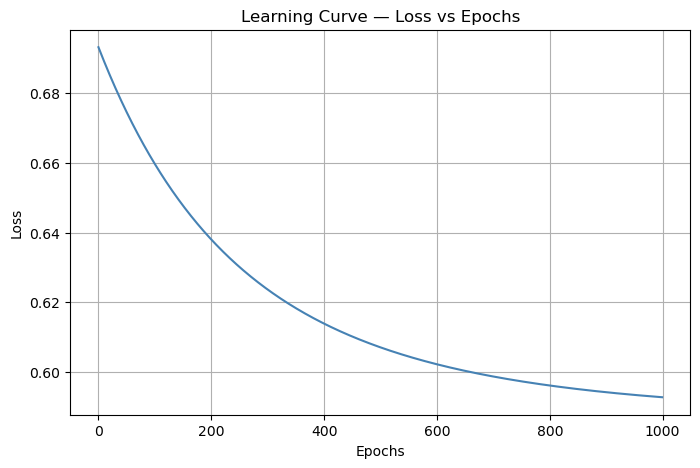

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history, color='steelblue')
plt.title('Learning Curve — Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.savefig('learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Evaluate The Model

In [14]:
# Step 1 — final predictions
# probability >= 0.5 → predict 1 (survived)
# probability < 0.5  → predict 0 (not survived)

z            = np.dot(X_norm, weights) + bias
final_probs  = sigmoid(z)
y_final_pred = (final_probs >= 0.5).astype(int)

# Step 2 — accuracy
accuracy = np.mean(y_final_pred == y)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7026


# Print Confusion Matrix

In [15]:
import numpy as np

TP = np.sum((y_final_pred == 1) & (y == 1))
TN = np.sum((y_final_pred == 0) & (y == 0))
FP = np.sum((y_final_pred == 1) & (y == 0))
FN = np.sum((y_final_pred == 0) & (y == 1))

Precision = TP / (TP + FP)
Recall    = TP / (TP + FN)

print("=" * 30)
print("    CONFUSION MATRIX RESULTS")
print("=" * 30)
print(f"  True Positive  (TP) : {TP}")
print(f"  True Negative  (TN) : {TN}")
print(f"  False Positive (FP) : {FP}")
print(f"  False Negative (FN) : {FN}")
print("-" * 30)
print(f"  Precision           : {Precision:.2f}")
print(f"  Recall              : {Recall:.2f}")
print("=" * 30)

    CONFUSION MATRIX RESULTS
  True Positive  (TP) : 155
  True Negative  (TN) : 471
  False Positive (FP) : 78
  False Negative (FN) : 187
------------------------------
  Precision           : 0.67
  Recall              : 0.45


# Verify Using SKLearn

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression()
model.fit(X_norm, y)
y_sklearn_pred = model.predict(X_norm)

print(f"Sklearn Accuracy : {accuracy_score(y, y_sklearn_pred):.4f}")
print(f"Your Accuracy    : {accuracy:.4f}")
print("\nSklearn Full Report:")
print(classification_report(y, y_sklearn_pred))

Sklearn Accuracy : 0.7003
Your Accuracy    : 0.7026

Sklearn Full Report:
              precision    recall  f1-score   support

           0       0.71      0.86      0.78       549
           1       0.66      0.45      0.54       342

    accuracy                           0.70       891
   macro avg       0.69      0.65      0.66       891
weighted avg       0.69      0.70      0.69       891

